In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from statsmodels.stats.mediation import Mediation
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
from pingouin import ancova
import matplotlib.cm as cm
from scipy.stats.stats import pearsonr


%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

/tmp/ipykernel_859566/3379509306.py:18: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr


# 1 Load data from "2 BrainAge"

In [147]:
# load data from pickle and convert to dataframe
main_test = pd.read_pickle("2_main_test.pkl")
main_train = pd.read_pickle("2_main_train.pkl")
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

# 2 Preprocessing and descriptives

## 2.1 Data

In [148]:
main_test.head()

,ID,Age,Sex,IS,TPA,VPA,MPA,MVPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,BADA2009,BADASEG,BADDesikan,BADCombined
10,1001365,71.0,Female,11025,3396.9600,20.1600,514.0800,554.4000,2862.7200,594.0,240.0,240.0,20.0,73.0,28.2030,70.0,106.0,-3.456312,-5.861078,-0.753998,-4.509657
17,1001748,48.0,Female,11025,3126.8160,265.3056,596.9376,1127.5488,2264.5728,462.0,0.0,2400.0,34.0,52.0,25.7857,75.0,124.0,4.634405,-2.724801,4.962128,-0.305375
20,1001984,69.0,Female,11026,2468.4192,9.9936,579.6288,599.6160,1878.7968,693.0,960.0,0.0,26.0,76.0,25.7422,79.0,120.0,1.435593,-4.006777,-7.437748,-0.498104
21,1002138,56.0,Female,11025,2465.2224,29.1168,427.0464,485.2800,2009.0592,2970.0,720.0,240.0,18.0,56.0,33.5680,75.0,134.0,-4.298338,-11.856106,1.921938,-4.787912
23,1002288,63.0,Female,11025,2559.7728,109.1376,704.4336,922.7088,1746.2016,264.0,960.0,0.0,30.0,85.0,27.4762,84.0,146.0,-4.784892,-4.467346,-4.335525,-3.692803


## 2.2 Remove outliers on SR PA

In [149]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 563
5422


## 2.3 Convert SRPA from MET min/week to min/week

In [150]:
main_test["SRLPA"] = main_test["SRLPA"]/3.3
main_test["SRMPA"] = main_test["SRMPA"]/4
main_test["SRVPA"] = main_test["SRVPA"]/8

main_train["SRLPA"] = main_train["SRLPA"]/3.3
main_train["SRMPA"] = main_train["SRMPA"]/4
main_train["SRVPA"] = main_train["SRVPA"]/8

## 2.4 Remove people with Gender other than Male or Female

In [151]:
before = main_test.shape[0]
main_test = main_test[(main_test["Sex"] == "Female") | (main_test["Sex"] == "Male")]
after = main_test.shape[0]
print("Sex not Male or Female:", before-after)
print(after)

Sex not Male or Female: 0
5422


## 2.5 Test set descriptives

In [152]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Sex"] == "Female"]
male = main_test[main_test["Sex"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_test["Age"].mean()
print("Mean", mean)
std = main_test["Age"].std()
print("Std",std)

print("LPA")
mean = main_test["LPA"].mean()
print("Mean", mean)
std = main_test["LPA"].std()
print("Std",std)

print("MPA")
mean = main_test["MPA"].mean()
print("Mean", mean)
std = main_test["MPA"].std()
print("Std",std)

print("VPA")
mean = main_test["VPA"].mean()
print("Mean", mean)
std = main_test["VPA"].std()
print("Std",std)

print("SRLPA")
mean = main_test["SRLPA"].mean()
print("Mean", mean)
std = main_test["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_test["SRMPA"].mean()
print("Mean", mean)
std = main_test["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_test["SRVPA"].mean()
print("Mean", mean)
std = main_test["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_test["DBP"].mean()
print("Mean", mean)
std = main_test["DBP"].std()
print("Std",std)

print("SBP")
mean = main_test["SBP"].mean()
print("Mean", mean)
std = main_test["SBP"].std()
print("Std",std)

print("BMI")
mean = main_test["BMI"].mean()
print("Mean", mean)
std = main_test["BMI"].std()
print("Std",std)

print("HG")
mean = main_test["HG"].mean()
print("Mean", mean)
std = main_test["HG"].std()
print("Std",std)

print("HR")
mean = main_test["HR"].mean()
print("Mean", mean)
std = main_test["HR"].std()
print("Std",std)

print("IS")
print(main_test["IS"].value_counts())

Number of females: 2898
NUmber of males: 2524
Age
Mean 64.42456658059757
Std 7.746236362094369
LPA
Mean 1976.847024123939
Std 415.15230248082173
MPA
Mean 484.2255359645888
Std 223.43063077111645
VPA
Mean 33.850217041682065
Std 44.54301033256454
SRLPA
Mean 233.9857985983032
Std 216.24792076864688
SRMPA
Mean 158.63353006270748
Std 191.35229826700072
SRVPA
Mean 64.06307635558835
Std 82.60736773994667
DBP
Mean 81.12652157875323
Std 10.413487966847205
SBP
Mean 136.59553670232387
Std 18.801323470648573
BMI
Mean 26.338654463297672
Std 4.231620807724451
HG
Mean 33.6119513094799
Std 10.947389284412296
HR
Mean 67.9821099225378
Std 10.694628178678567
IS
11025    3330
11027    1151
11026     936
11028       5
Name: IS, dtype: int64


## 2.6 Train set descriptives

In [153]:
# get mean and std for all variables for males and females seperately for the test set
female = main_train[main_train["Sex"] == "Female"]
male = main_train[main_train["Sex"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_train["Age"].mean()
print("Mean", mean)
std = main_train["Age"].std()
print("Std",std)

print("SRLPA")
mean = main_train["SRLPA"].mean()
print("Mean", mean)
std = main_train["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_train["SRMPA"].mean()
print("Mean", mean)
std = main_train["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_train["SRVPA"].mean()
print("Mean", mean)
std = main_train["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_train["DBP"].mean()
print("Mean", mean)
std = main_train["DBP"].std()
print("Std",std)

print("SBP")
mean = main_train["SBP"].mean()
print("Mean", mean)
std = main_train["SBP"].std()
print("Std",std)

print("BMI")
mean = main_train["BMI"].mean()
print("Mean", mean)
std = main_train["BMI"].std()
print("Std",std)

print("HG")
mean = main_train["HG"].mean()
print("Mean", mean)
std = main_train["HG"].std()
print("Std",std)

print("HR")
mean = main_train["HR"].mean()
print("Mean", mean)
std = main_train["HR"].std()
print("Std",std)

print("IS")
print(main_test["IS"].value_counts())

Number of females: 11117
NUmber of males: 10325
Age
Mean 64.39889002891522
Std 7.649732872523935
SRLPA
Mean 289.784948011223
Std 309.29411344455514
SRMPA
Mean 206.94867139792044
Std 280.6411674181547
SRVPA
Mean 82.22308411729108
Std 130.49491812800625
DBP
Mean 81.29120713856025
Std 10.363904029343296
SBP
Mean 136.45067174654102
Std 18.67013239738352
BMI
Mean 26.645524985989166
Std 4.237943939447412
HG
Mean 33.90108039848464
Std 11.262323642066619
HR
Mean 68.077150591538
Std 10.972897755270589
IS
11025    3330
11027    1151
11026     936
11028       5
Name: IS, dtype: int64


## 2.8 Physical activity

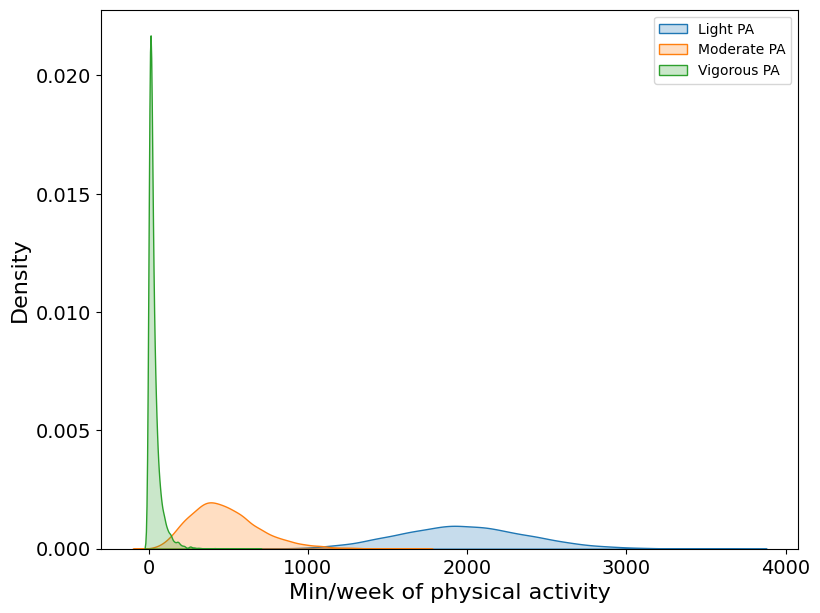

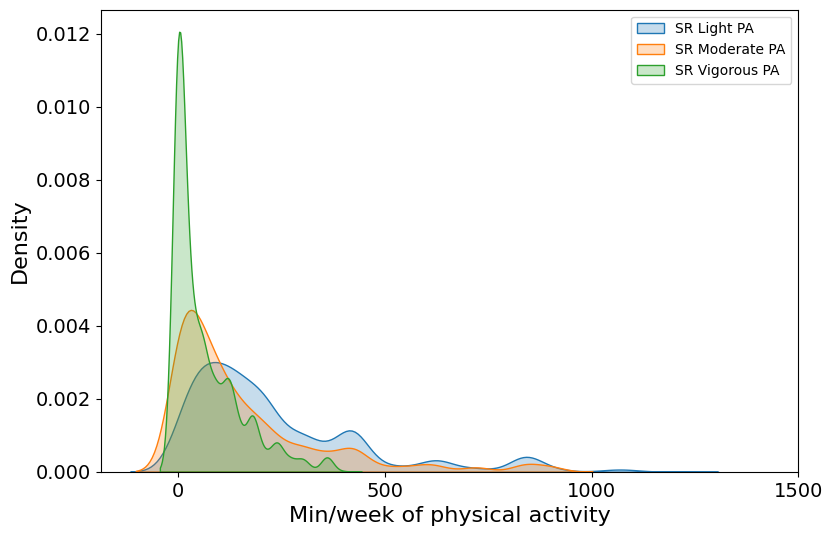

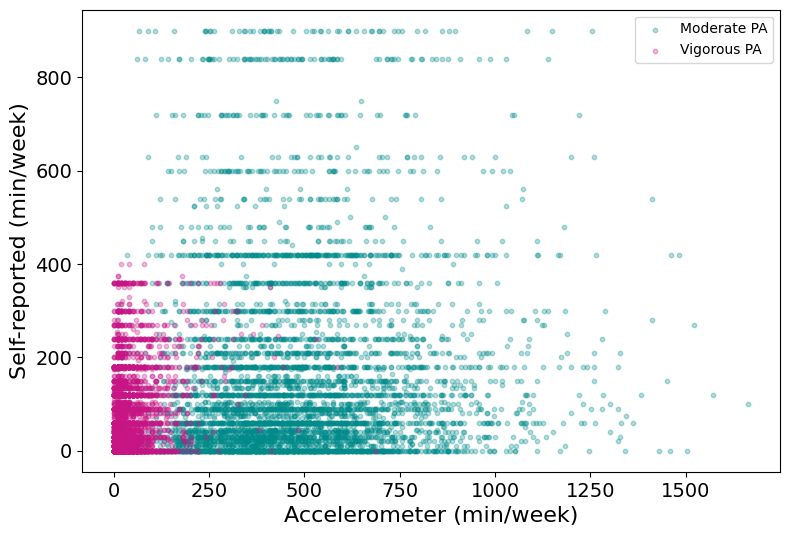

In [154]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately

plt.figure(figsize=(9,7))
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,5000,1000),fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.yticks(fontsize = 14)
plt.legend()
plt.savefig('mainpa.png', format='png', dpi=800)
plt.show()

plt.figure(figsize=(9,6))
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,2000,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.savefig('mainsrpa.png', format='png', dpi=800)
plt.legend()
plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
# sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,4500,1000),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
# sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,2500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
# sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
# plt.ylim(0,0.01)
# plt.xticks(range(0,1500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.legend()
# plt.show()

plt.figure(figsize=(9,6))
plt.scatter("MPA", "SRMPA", data = main_test, label = "Moderate PA", alpha=0.3, s=10, color = "darkcyan")
plt.scatter("VPA", "SRVPA", data = main_test, label = "Vigorous PA", alpha=0.3, s=10, color = "mediumvioletred")
plt.ylabel("Self-reported (min/week)", fontsize = 16)
plt.xlabel("Accelerometer (min/week)", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc="best")
plt.savefig('mainpascat.png', format='png', dpi=800)
plt.show()

# 3 Recode variables

In [155]:
# recode Imaging site and Gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 0, '11026': 1,'11027': 2, '11028': 3})
main_test["Sex"] = main_test["Sex"].map({"Female":0, "Male":1})
main_test["Sex"] = main_test["Sex"].astype("int")
main_test = main_test.rename(columns={"BADCombined": "BA"})

# 4 Reorder dataframe and delete unused variables

In [156]:
main_test = main_test[['Age', 'Sex', 'IS' , 'LPA', 'MPA', 'VPA', 'SRLPA', 'SRMPA', 'SRVPA', 'HG', 'HR', 'BMI', 'DBP', 'SBP', 'BA']]

# 5 Standardization of all variables

In [157]:
main_test = pd.DataFrame(main_test)
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex","IS"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex","IS"]], nan_policy='omit')

# 6 Correlation heatmap

In [158]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

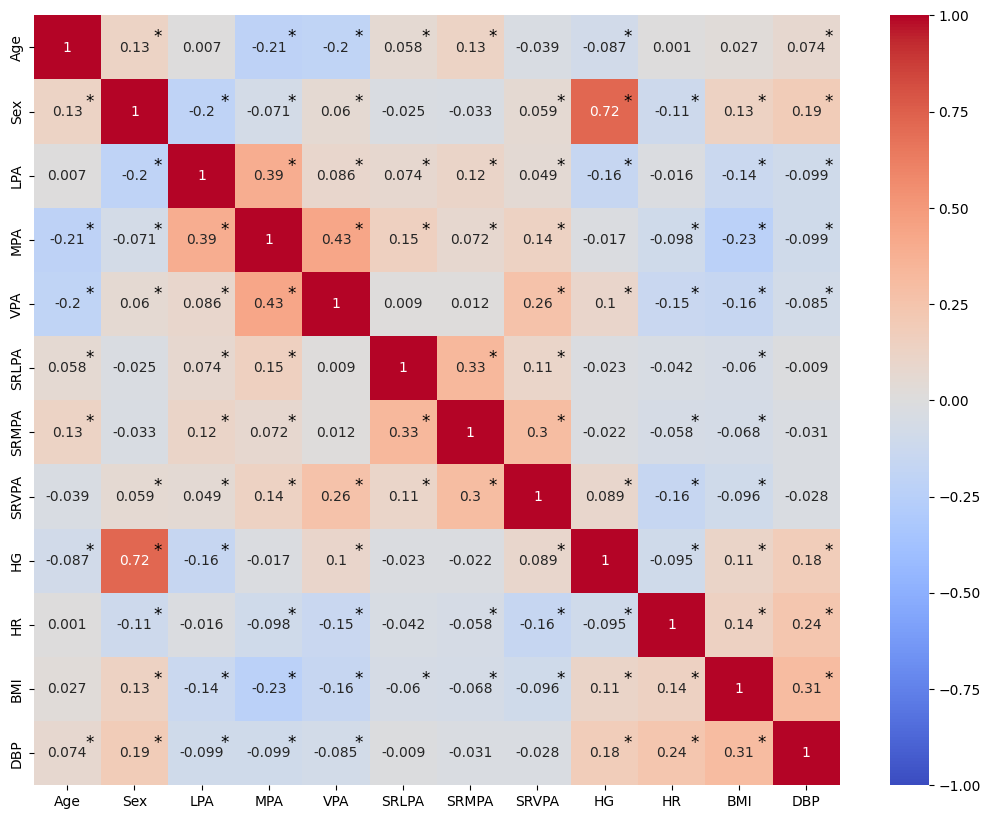

In [159]:
corr_test = main_test
corr_test = corr_test[:]
del corr_test["BA"]
del corr_test["SBP"]
del corr_test["IS"]
corr = corr_test.corr()
corr = round(corr,3)

fig, ax = plt.subplots(figsize=(13,10)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)


p_values = np.asarray(calculate_pvalues(corr_test))

threshold = 0.0007575  

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i != j:
            correlation = corr.iloc[i, j]
            p_value = p_values[i,j] 

            if p_value < threshold:
                ax.text(j + 0.9, i + 0.2, "*", ha='right', va='top', color='black', fontsize=12)
                
plt.savefig('mainheatmap.png', format='png', dpi=800)               
plt.show()

# 7 Models OLS

## 7.1 Baseline Covariates

In [160]:
cov_model = ols('BA ~ Sex + Age + IS', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     7.568
Date:                Sat, 30 Nov 2024   Prob (F-statistic):           4.76e-05
Time:                        02:09:29   Log-Likelihood:                -17211.
No. Observations:                5422   AIC:                         3.443e+04
Df Residuals:                    5418   BIC:                         3.446e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2130      0.079     -2.710      0.0

## 7.2 Accelerometer PA

In [161]:
lpa = ols('BA ~ LPA + Age + Sex + IS + Sex:LPA', missing='drop', data = main_test).fit()
print(lpa.summary())

#calculate effect size
results = lpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.780
Date:                Sat, 30 Nov 2024   Prob (F-statistic):           0.000232
Time:                        02:09:29   Log-Likelihood:                -17210.
No. Observations:                5422   AIC:                         3.443e+04
Df Residuals:                    5416   BIC:                         3.447e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2112      0.080     -2.630      0.0

In [162]:
mpa = ols('BA ~ MPA + Age + Sex + IS + Sex:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     7.392
Date:                Sat, 30 Nov 2024   Prob (F-statistic):           6.43e-07
Time:                        02:09:29   Log-Likelihood:                -17204.
No. Observations:                5422   AIC:                         3.442e+04
Df Residuals:                    5416   BIC:                         3.446e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2306      0.079     -2.930      0.0

In [163]:
vpa = ols('BA ~ VPA + Age + Sex + IS + Sex:VPA', missing='drop', data = main_test).fit()
print(vpa.summary())

#calculate effect size
results = vpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.812
Date:                Sat, 30 Nov 2024   Prob (F-statistic):           2.33e-05
Time:                        02:09:29   Log-Likelihood:                -17208.
No. Observations:                5422   AIC:                         3.443e+04
Df Residuals:                    5416   BIC:                         3.447e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2022      0.079     -2.569      0.0

## 7.3 Self-report PA

In [164]:
srlpa = ols('BA ~ SRLPA + Age + Sex + IS + Sex:SRLPA', missing='drop', data = main_test).fit()
print(srlpa.summary())

#calculate effect size
results = srlpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.198
Date:                Sat, 30 Nov 2024   Prob (F-statistic):           9.18e-05
Time:                        02:09:29   Log-Likelihood:                -17209.
No. Observations:                5422   AIC:                         3.443e+04
Df Residuals:                    5416   BIC:                         3.447e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2157      0.079     -2.744      0.0

In [165]:
srmpa = ols('BA ~ SRMPA + Age + Sex + IS + Sex:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.349
Date:                Sat, 30 Nov 2024   Prob (F-statistic):           6.56e-05
Time:                        02:09:29   Log-Likelihood:                -17209.
No. Observations:                5422   AIC:                         3.443e+04
Df Residuals:                    5416   BIC:                         3.447e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2178      0.079     -2.771      0.0

In [166]:
srvpa = ols('BA ~ SRVPA + Age + Sex + IS + Sex:SRVPA', missing='drop', data = main_test).fit()
print(srvpa.summary())

#calculate effect size
results = srvpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.460
Date:                Sat, 30 Nov 2024   Prob (F-statistic):           5.13e-05
Time:                        02:09:29   Log-Likelihood:                -17209.
No. Observations:                5422   AIC:                         3.443e+04
Df Residuals:                    5416   BIC:                         3.447e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2041      0.079     -2.593      0.0

# 8 Model comparisons

## 8.1 Cov vs. PA

In [167]:
model_comparison = anova_lm(cov_model, lpa)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff        F    Pr(>F)
0    5418.0  181470.267619      0.0        NaN      NaN       NaN
1    5416.0  181430.072308      2.0  40.195311  0.59995  0.548876


In [168]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  181470.267619      0.0         NaN       NaN       NaN
1    5416.0  180995.562063      2.0  474.705556  7.102399  0.000831


In [169]:
model_comparison = anova_lm(cov_model, vpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  181470.267619      0.0         NaN       NaN       NaN
1    5416.0  181258.240077      2.0  212.027542  3.167694  0.042179


## 8.2 Cov vs. SRPA

In [170]:
model_comparison = anova_lm(cov_model, srlpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  181470.267619      0.0         NaN       NaN       NaN
1    5416.0  181360.339272      2.0  109.928347  1.641406  0.193804


In [171]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  181470.267619      0.0         NaN       NaN       NaN
1    5416.0  181335.242900      2.0  135.024719  2.016414  0.133232


In [172]:
model_comparison = anova_lm(cov_model, srvpa)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5418.0  181470.267619      0.0        NaN       NaN       NaN
1    5416.0  181316.832929      2.0  153.43469  2.291575  0.101205


# 9 Mediation analysis

## 9.1 BMI

In [173]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
# print(res.summary())

In [174]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA + Age + Sex + IS", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA + Age + Sex + IS", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

modelm = ols("BMI ~ MPA + Age + Sex + IS", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ BMI + Age + Sex + IS", missing='drop', data = main_test).fit()
print(modely.summary())

KeyboardInterrupt: 

In [ ]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
# print(res.summary())

## 9.2 DBP

In [ ]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
# print(res.summary())

In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA + Age + Sex + IS", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA + Age + Sex + IS", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

modelm = ols("DBP ~ MPA + Age + Sex + IS", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ DBP + Age + Sex + IS", missing='drop', data = main_test).fit()
print(modely.summary())

KeyboardInterrupt: 

In [ ]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
# print(res.summary())

## 9.3 Heart rate

In [ ]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
# print(res.summary())

In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA + Age + Sex + IS", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA + Age + Sex + IS", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HR ~ MPA + Age + Sex + IS", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HR + Age + Sex + IS", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.041778       -0.069260       -0.018423    0.000
ACME (treated)           -0.041778       -0.069260       -0.018423    0.000
ADE (control)            -0.123570       -0.268823        0.024482    0.120
ADE (treated)            -0.123570       -0.268823        0.024482    0.120
Total effect             -0.165348       -0.316762       -0.015159    0.026
Prop. mediated (control)  0.249395        0.082610        1.726624    0.026
Prop. mediated (treated)  0.249395        0.082610        1.726624    0.026
ACME (average)           -0.041778       -0.069260       -0.018423    0.000
ADE (average)            -0.123570       -0.268823        0.024482    0.120
Prop. mediated (average)  0.249395        0.082610        1.726624    0.026
                            OLS Regression Results                            
Dep. Variable:                     HR   R-squared:                       0.026
Model:

In [ ]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
# print(res.summary())

## 9.4 Hand grip

In [ ]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
# print(res.summary())

In [ ]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA + Sex + Age + IS", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA + Sex + Age + IS", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HG ~ MPA + Age + Sex + IS", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HG + Age + Sex + IS", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.001897       -0.011827        0.016625    0.754
ACME (treated)            0.001897       -0.011827        0.016625    0.754
ADE (control)            -0.169346       -0.320519       -0.017187    0.040
ADE (treated)            -0.169346       -0.320519       -0.017187    0.040
Total effect             -0.167449       -0.314348       -0.018892    0.034
Prop. mediated (control) -0.010170       -0.196530        0.122312    0.760
Prop. mediated (treated) -0.010170       -0.196530        0.122312    0.760
ACME (average)            0.001897       -0.011827        0.016625    0.754
ADE (average)            -0.169346       -0.320519       -0.017187    0.040
Prop. mediated (average) -0.010170       -0.196530        0.122312    0.760
                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.555
Model:

In [ ]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + VPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ VPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
# print(res.summary())

# 10 LASSO Regression

## 10.1 Accelerometer PA

Optimal alpha: 0.003511191734215131


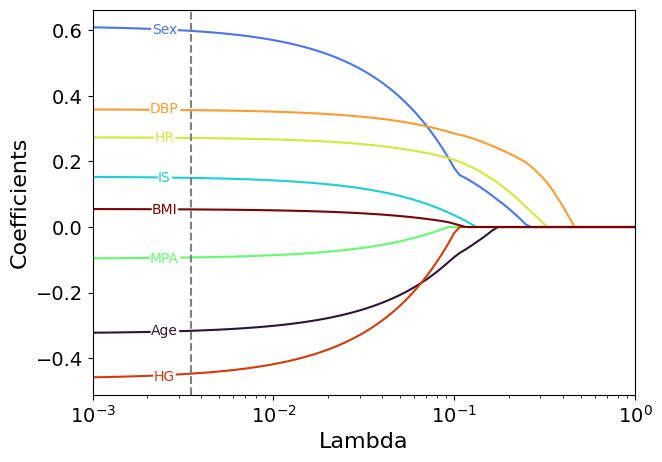

[-0.31684904  0.59872457  0.14995349 -0.09281329  0.27185967  0.35691423
 -0.44770533  0.05373783]
0.015163140925173457


In [ ]:
df = main_test[["Age","Sex","IS", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age","Sex","IS", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age","Sex","IS", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=0, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas, random_state=888).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)



cmap = cm.get_cmap('turbo')
plt.figure(figsize=(7,5))
for i, column in enumerate(columns):
    plt.plot(alphas, coefs[column], label=column, color=cmap(i / (len(columns) - 1)))

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    color = cmap(i / 7.0)

    if i == 1:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -5),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    else:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -3),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white',edgecolor="white", pad=0))
        
        
plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.xlim(0.001, 1)
plt.ylabel('Coefficients', fontsize = 16)
plt.legend().set_visible(False)
plt.savefig('mainlasso.png', format='png', dpi=800)
plt.show()

# Print the coefficients
print(coefficients)
print(r_squared)

## 10.2 Self-report PA

Optimal alpha: 0.0030538555088334154


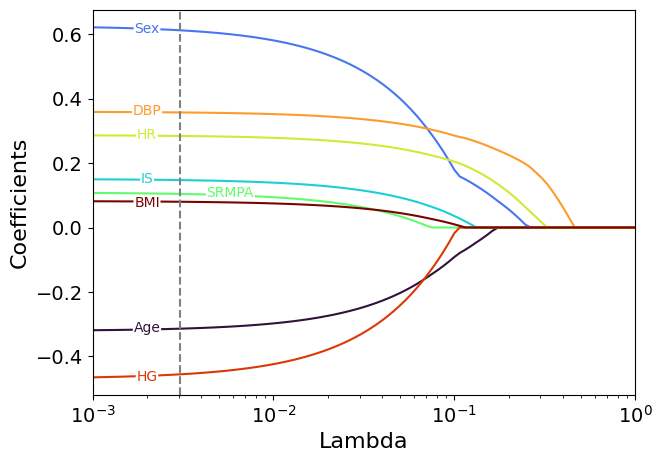

[-0.31428817  0.61269089  0.14736395  0.10433918  0.284444    0.35751144
 -0.45610209  0.08001482]
0.015258275217532202


In [ ]:
df = main_test[["Age", "Sex", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Sex", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Sex", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=0, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('turbo')
plt.figure(figsize=(7,5))
for i, column in enumerate(columns):
    plt.plot(alphas, coefs[column], label=column, color=cmap(i / (len(columns) - 1)))

# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas, random_state=888).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)


# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    color = cmap(i / 7.0)
    
    if i == 3:
        plt.annotate(column, (0.002, y_pos), textcoords="offset points", xytext=(60, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (0.002, y_pos), textcoords="offset points", xytext=(0, -5),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 1:
        plt.annotate(column, (0.002, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (0.002, y_pos), textcoords="offset points", xytext=(0, -4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    else:
        plt.annotate(column, (0.002, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white',edgecolor="white", pad=0))


plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.xlim(0.001, 1)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
#plt.legend(columns, bbox_to_anchor=(1.01, 1.02), loc='upper left')
plt.legend().set_visible(False)
plt.savefig('mainlassosr.png', format='png', dpi=800)
plt.show()


# Print the coefficients
print(coefficients)
print(r_squared)